# Training Image-to-Text Model Notebook

In this notebook we will be describing the steps taken to train the Image-to-Text Model used within our application. We will be following a similar format to those used within the assignments during CS 614.

The model training script will be in `core/image-to-text/train_trocr.py` 

## Imports and Installs

In this section we will be importing the packages needed to carry out this portion of the project

In [1]:
import numpy as np
import pandas as pd
import json
import os

# For accessing HuggingFace Datasets
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image

# For the Image-to-Text Model Pipeline
import torch
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    GenerationConfig,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    ViTImageProcessor,
    RobertaTokenizer,
    default_data_collator
)
import evaluate

/opt/anaconda3/envs/medicai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The Dataset

For training the Image-to-Text model for our specific task which is to take Medical Notes, Perscription notes, and hand written notes from Patients and convert them into text which can be used as further context for our application we will be utilizing the [RxHandBD: A Handwritten Prescription Word Image Dataset](https://data.mendeley.com/datasets/dsb5r6vskg/3)

This dataset will expose the model to difficult to read handwriting and allow us to guage how well the model is able to capture the word.

In [2]:
train_image_file_path = '../data/RxHandBD A Handwritten Prescription Word Image Dat/RxHandBD-ML/Train_Set'

test_img_file_path = '../data/RxHandBD A Handwritten Prescription Word Image Dat/RxHandBD-ML/Test_Set'

train_truth_label_file_path = '../data/RxHandBD A Handwritten Prescription Word Image Dat/RxHandBD-ML/Train_Label.csv'

test_truth_label_file_path = '../data/RxHandBD A Handwritten Prescription Word Image Dat/RxHandBD-ML/Test_Label.csv'

In [3]:
truth_label_df = pd.read_csv(train_truth_label_file_path)
truth_label_df.head()

,Images,Text
0,P1116.jpg,Dexter
1,P1117.jpg,Clavusef sw
2,P1118.jpg,m-lucas 10
3,P1119.jpg,Dophyllin
4,P1120.jpg,Delfian


For our training data we have a well organized table that gives us both the name of the image and a description of the text within the image. This will help us when fine tuning the model as we can directly test whether or not the model accurately generated the text.

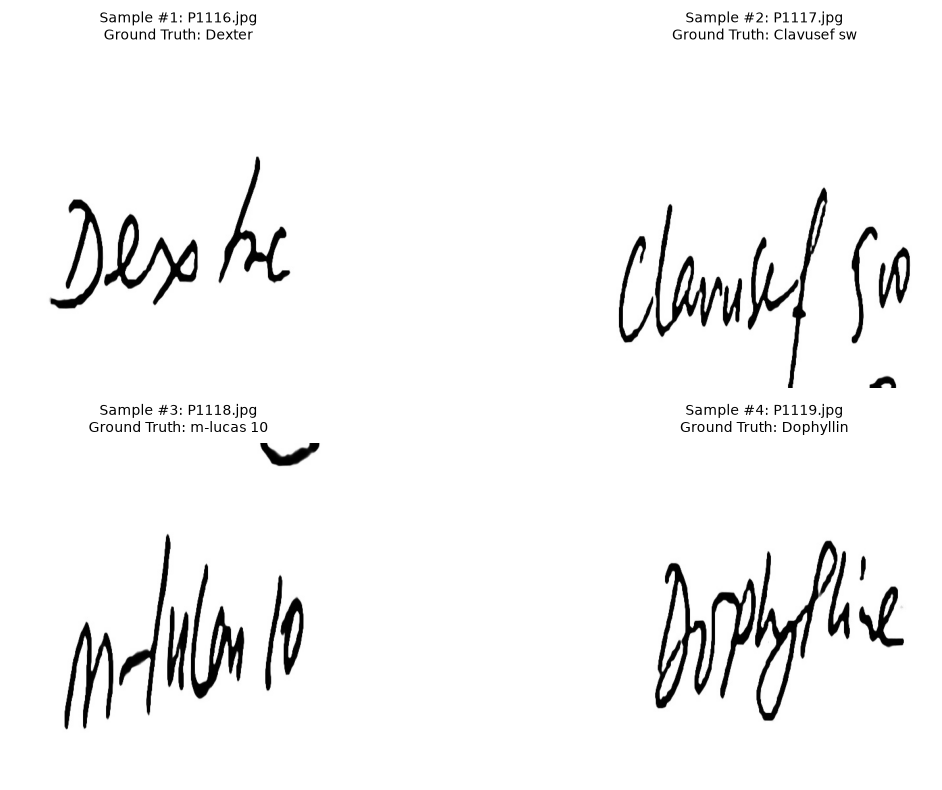

In [4]:
# Looping throuh first 4 rows to provide image example and truth label 

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
axes_flat = axes.flatten()

for idx, (_, row) in enumerate(truth_label_df.head(4).iterrows()):
    img_name = row['Images']
    ground_truth = str(row['Text'])

    img_path = os.path.join(train_image_file_path, os.path.basename(img_name))

    if os.path.exists(img_path):
        img = Image.open(img_path).convert("RGB")
        axes_flat[idx].imshow(img)
    else:
        axes_flat[idx].text(0.5, 0.5, f"File Not Found:\n{img_name}", ha="center", va="center", color="red")
        
    axes_flat[idx].axis("off")
    # Wrap text cleanly in title
    axes_flat[idx].set_title(f"Sample #{idx + 1}: {img_name}\nGround Truth: {ground_truth[:80]}", fontsize=10, pad=8)

plt.tight_layout()
plt.show()

## The Model

For the model we will be using to carryout out Image-to-Text transformation, we will be using the `Microsoft TROCR Model` which is a line by line text to image classifier. We will be using the RxHand dataset to train and fine tune the model for the task we need it to do

In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [6]:
MODEL_NAME = "microsoft/trocr-base-handwritten"

# 1. Load image processor and tokenizer independently
image_processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

# 2. Combine into processor
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

# 3. Load model weights
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)

# 4. Set special token IDs on top-level model.config (resolves AttributeError)
pad_token_id = processor.tokenizer.pad_token_id
decoder_start_token_id = (
    processor.tokenizer.cls_token_id or processor.tokenizer.bos_token_id
)
eos_token_id = (
    processor.tokenizer.sep_token_id or processor.tokenizer.eos_token_id
)

model.config.pad_token_id = pad_token_id
model.config.decoder_start_token_id = decoder_start_token_id
model.config.eos_token_id = eos_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# Also set them on decoder config for consistency
model.config.decoder.pad_token_id = pad_token_id
model.config.decoder.decoder_start_token_id = decoder_start_token_id
model.config.decoder.eos_token_id = eos_token_id

# 5. Configure GenerationConfig (handles max_length and beam search)
model.generation_config = GenerationConfig.from_pretrained(MODEL_NAME)
model.generation_config.decoder_start_token_id = decoder_start_token_id
model.generation_config.pad_token_id = pad_token_id
model.generation_config.eos_token_id = eos_token_id
model.generation_config.max_length = 64
model.generation_config.early_stopping = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty = 2.0
model.generation_config.num_beams = 4

print("TrOCR Processor & Model loaded successfully!")

Loading weights: 100%|██████████| 478/478 [00:00<00:00, 7713.53it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR Processor & Model loaded successfully!


In [7]:
from torch.utils.data import Dataset

class RxHandDataset(Dataset):
    def __init__(self, df, img_dir, processor, max_target_length=64):
        self.df = df.dropna(subset=['Text']).reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['Images']
        text = str(row['Text'])

        # Load image
        img_path = os.path.join(self.img_dir, os.path.basename(img_name))
        image = Image.open(img_path).convert("RGB")

        # Preprocess visual features for ViT encoder
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze(0)

        # Tokenize target text for Roberta decoder
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True
        ).input_ids

        # Set pad tokens to -100 so Cross-Entropy loss ignores padding
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(labels, dtype=torch.long)
        }

In [8]:
# Load Test Labels DataFrame
test_truth_label_df = pd.read_csv(test_truth_label_file_path)

# Instantiate PyTorch Datasets
train_dataset = RxHandDataset(truth_label_df, train_image_file_path, processor)
test_dataset = RxHandDataset(test_truth_label_df, test_img_file_path, processor)

print(f"Total Training Samples: {len(train_dataset)}")
print(f"Total Testing/Validation Samples: {len(test_dataset)}")

Total Training Samples: 4463
Total Testing/Validation Samples: 1115


### Evaluation Metrics

For training the TROCR model we have very specific evaluation metrics to ensure that the model is 

In [9]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

    # Replace -100 with the pad token id before decoding ground truth
    labels_ids = np.where(labels_ids != -100, labels_ids, processor.tokenizer.pad_token_id)
    label_str = processor.tokenizer.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    return {"cer": round(cer, 4), "wer": round(wer, 4)}

### Zero-Shot Test

In this test we will be using a small subset of 20 images from the test set to apply to the TROCR model out of the box to establish a baseline that we can use to improve the model upon.

In [10]:
from torch.utils.data import Subset

# Test on 20 samples
subset_test = Subset(test_dataset, range(min(20, len(test_dataset))))

eval_args = Seq2SeqTrainingArguments(
    output_dir="../models/model_checkpoints/trocr_baseline_eval",
    predict_with_generate=True,
    per_device_eval_batch_size=8,
    report_to="none"
)

baseline_trainer = Seq2SeqTrainer(
    model=model,
    args=eval_args,
    processing_class=processor.tokenizer,  # Fixed to processor.tokenizer
    compute_metrics=compute_metrics,
    eval_dataset=subset_test,
    data_collator=default_data_collator
)

print("Evaluating Baseline TrOCR (Zero-Shot)...")
baseline_metrics = baseline_trainer.evaluate()
print("Baseline Metrics:", baseline_metrics)

Evaluating Baseline TrOCR (Zero-Shot)...


/opt/anaconda3/envs/medicai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Cer,Wer
No log,11.685268,0,0.684600,1.909100


Baseline Metrics: {'eval_loss': 11.68526840209961, 'eval_cer': 0.6846, 'eval_wer': 1.9091}


Now that out the zero-shot baseline of the trocr model we see that we have a Cross Entropy Evaluation loss of around 11 which is a very high value for the metric, meaning that the 

### Fine-Tuning the Model

In this step we will be deciding our hyperparameters that will best help us gain the maximum performance from the model.

In [11]:
training_args = Seq2SeqTrainingArguments(
    output_dir="../models/model_checkpoints/trocr_rxhand_checkpoints",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    fp16=False,  #Set to False for Mac, else use: torch.cuda.is_available()
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    weight_decay=0.01,
    num_train_epochs=3,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor.tokenizer,  # Fixed to processor.tokenizer
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=default_data_collator
)

# Run Training
trainer.train()

print("Evaluating Fine-Tuned TrOCR metrics...")
ft_metrics = trainer.evaluate()
print("Fine-Tuned TrOCR Metrics:", ft_metrics)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


Epoch,Training Loss,Validation Loss,Cer,Wer
1,0.814287,1.794526,0.336200,0.738100
2,0.468968,1.689348,0.295000,0.694400
3,0.159889,1.873031,0.285900,0.672600


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.39s/it]
/opt/anaconda3/envs/medicai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.26s/it]
/opt/anaconda3/envs/medicai/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.46s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['encoder.layers.0.attention.q_proj.weight', 'encoder.layers.0.attention.k_proj.weight', 'encoder.layers.0.attention.v_proj.weight', 'encoder.layers.0.attention.o_proj.weight', 'encoder.layers.0.attention.o_proj.bias', 'encoder.layers.0.layernorm_before

Evaluating Fine-Tuned TrOCR metrics...


Training Loss,Validation Loss,Epoch,Cer,Wer
0.159889,1.873031,3,0.285900,0.672600


Fine-Tuned TrOCR Metrics: {'eval_loss': 1.8730310201644897, 'eval_cer': 0.2859, 'eval_wer': 0.6726}


### Plotting Training Metrics

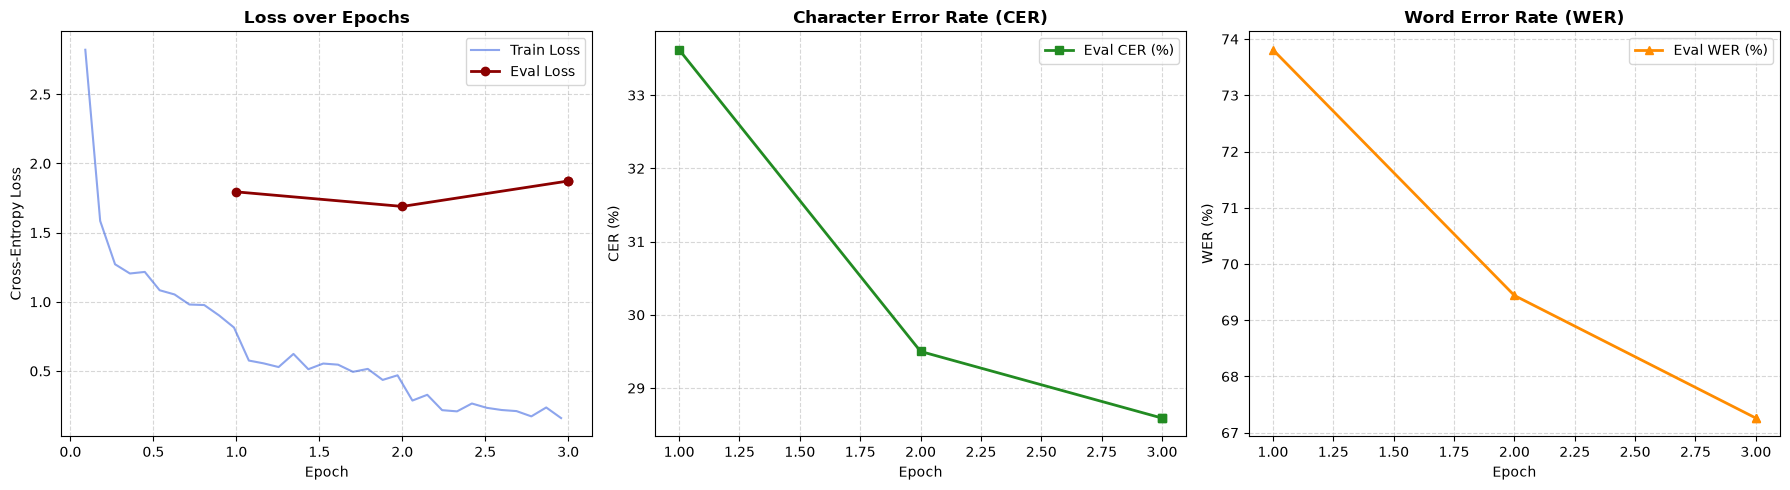

In [12]:
# 1. Extract logs from trainer state
log_history = trainer.state.log_history

train_losses = []
eval_epochs = []
eval_losses = []
eval_cers = []
eval_wers = []

for log in log_history:
    # Capture training step losses
    if "loss" in log and "epoch" in log:
        train_losses.append({"epoch": log["epoch"], "train_loss": log["loss"]})
    
    # Capture evaluation metrics computed at each epoch
    if "eval_loss" in log and "eval_cer" in log:
        eval_epochs.append(log["epoch"])
        eval_losses.append(log["eval_loss"])
        eval_cers.append(log["eval_cer"])
        eval_wers.append(log.get("eval_wer", None))

df_train = pd.DataFrame(train_losses)

# 2. Create subplots for Loss, CER, and WER
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Training vs. Evaluation Loss
if not df_train.empty:
    axes[0].plot(df_train["epoch"], df_train["train_loss"], label="Train Loss", color="royalblue", alpha=0.6)
axes[0].plot(eval_epochs, eval_losses, label="Eval Loss", color="darkred", marker="o", linewidth=2)
axes[0].set_title("Loss over Epochs", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Subplot 2: Evaluation Character Error Rate (CER)
axes[1].plot(eval_epochs, [c * 100 for c in eval_cers], label="Eval CER (%)", color="forestgreen", marker="s", linewidth=2)
axes[1].set_title("Character Error Rate (CER)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CER (%)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

# Subplot 3: Evaluation Word Error Rate (WER)
if any(eval_wers):
    axes[2].plot(eval_epochs, [w * 100 for w in eval_wers if w is not None], label="Eval WER (%)", color="darkorange", marker="^", linewidth=2)
    axes[2].set_title("Word Error Rate (WER)", fontsize=12, fontweight="bold")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("WER (%)")
    axes[2].grid(True, linestyle="--", alpha=0.5)
    axes[2].legend()

plt.tight_layout()
plt.show()

In [13]:
# Save final fine-tuned model and processor
SAVE_PATH = "../models/trocr_final_mdl"
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)
print(f"Fine-tuned model successfully saved to {SAVE_PATH}")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]

Fine-tuned model successfully saved to ../models/trocr_final_mdl


[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

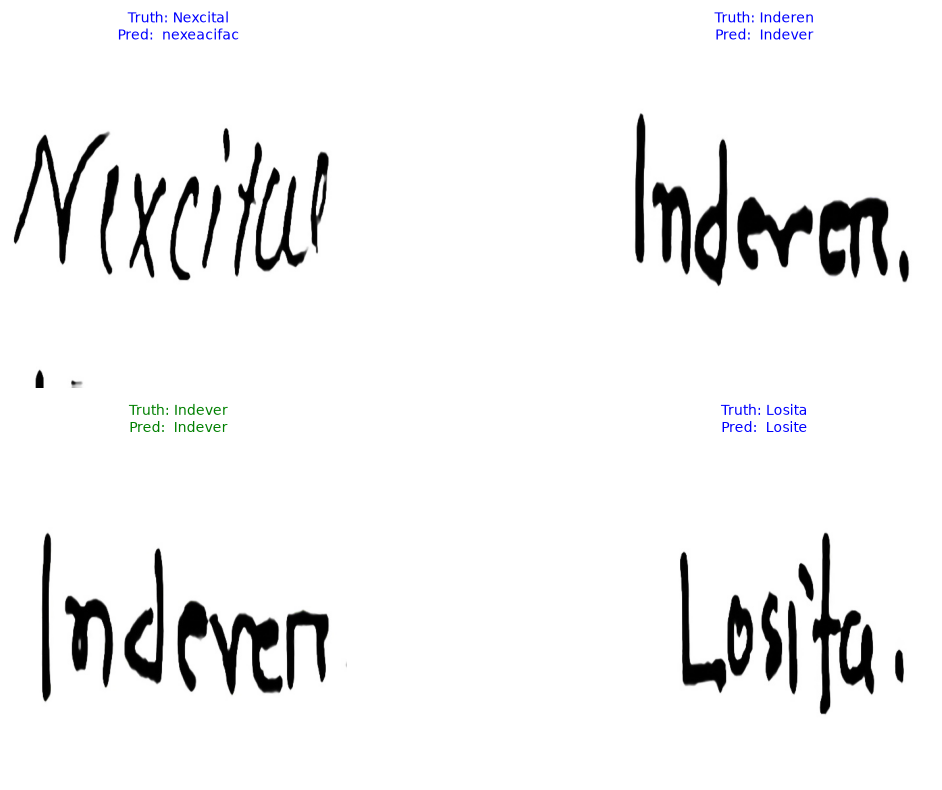

In [14]:
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    pixel_values = processor(img, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = model.generate(pixel_values, max_new_tokens=64)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# Display 4 Test Predictions
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
axes_flat = axes.flatten()

for idx, (_, row) in enumerate(test_truth_label_df.head(4).iterrows()):
    img_name = row['Images']
    ground_truth = str(row['Text'])
    img_path = os.path.join(test_img_file_path, os.path.basename(img_name))

    pred_text = predict_image(img_path)

    img = Image.open(img_path).convert("RGB")
    axes_flat[idx].imshow(img)
    axes_flat[idx].axis("off")
    axes_flat[idx].set_title(
        f"Truth: {ground_truth}\nPred:  {pred_text}",
        fontsize=10,
        pad=8,
        color="green" if ground_truth.strip().lower() == pred_text.strip().lower() else "blue"
    )

plt.tight_layout()
plt.show()